# 09 — The Brazilian rate curve, point in time (DUSTIN-BR)

**The question:** *Which public data can support a model of where the Brazilian
rate curve goes over the next month, and how is it assembled so that no row ever
uses information that was not yet public on its date?*

This notebook walks the study step by step, from the target (DI1 futures and
B3's own curve) to the drivers (inflation, the dollar, global rates, global
stress, commodities) to the one rule the whole dataset serves. The design is
inspired by HSBC's DUSTIN framework, which estimates the direction and regime
of a rate curve about 21 trading days ahead. **Nothing here builds a model or a
target**: labels look forward by definition and belong in the modelling
notebook. This is the data foundation, and the proof that it does not leak.

Two kinds of cells:

* **API cells** call SILO's public read API (catalog v42): `coverage`,
  `future_curve`, `curve`, `curve_history`.
* **Study cells** run the repository's own parsers and research builder on real
  files that B3, the U.S. Treasury and the U.S. Office of Financial Research
  published, kept under `tests/fixtures/`.
  They need a clone of the repository, not a database.

The written study, with every source tested and every rule's evidence, is
[`docs/reference/research/dustin_br_data_sources.md`](../docs/research/dustin_br_data_sources.md);
the builder is
[`research_examples/dustin_br/`](../research_examples/dustin_br/).

## Setup

In [2]:
# The SDK is not on PyPI. From the repository root:
#
#     pip install -e sdk/
#     pip install -r notebooks/requirements.txt
#
# Auth is the shared publishable key printed in the docs. It is for TESTING:
# everyone reading the docs has the same one, so it identifies the project and
# not you. It puts you on the ANONYMOUS tier.
import os
import sys
import textwrap
import matplotlib.pyplot as plt
from pathlib import Path

os.environ.setdefault("SILO_URL", "https://zcjbtpxuhdekpwcxmepn.supabase.co")
os.environ.setdefault(
    "SILO_ANON_KEY", "sb_publishable__yfFQsykAglrvc9GS6_PYw_B24ex437"
)

# The study cells import the repository's own parsers and research builder.
ROOT = Path.cwd().resolve()
while not (ROOT / "research_examples").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
FIX = ROOT / "tests" / "fixtures"

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from research_examples.dustin_br import build_dataset as bd
from silo_client import SiloClient
from silo_client.client import SiloError

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

silo = SiloClient()
print(f"tier            : {silo.tier}")
print(f"catalog version : {silo.catalog()['version']}")
print(f"repository      : {ROOT}")

tier            : anon
catalog version : 44
repository      : /Users/pedrotodescan/Dev/SILO-BZ


In [3]:
def as_of(*datasets: str) -> pd.DataFrame:
    """Print how fresh every dataset this notebook relies on actually is.

    Run this FIRST, every time. A stale warehouse then shows up in the output
    instead of being silently baked into a number further down.

      as_of            the newest period that has landed AND has elapsed.
      complete_through the newest period classified COMPLETE.
      newest_period    the newest period KEY present.
      landed_at        when ingest last SUCCEEDED. A later failed run never
                       advances it.
      notes            a caveat the dates cannot carry, printed in full.
    """
    cov = pd.DataFrame(silo.coverage())
    rows = cov[cov["dataset"].isin(datasets)].copy()
    missing = set(datasets) - set(rows["dataset"])
    if missing:
        raise RuntimeError(f"coverage() has no row for {sorted(missing)}")
    print(
        rows[
            ["dataset", "as_of", "complete_through", "newest_period", "landed_at"]
        ].to_string(index=False)
    )
    for r in rows.itertuples():
        if r.notes:
            print(f"\n  CAVEAT [{r.dataset}]\n  {r.notes}")
    return rows.set_index("dataset")

## Step 1 — Freshness first

Two datasets carry the rate curve: `di_futures` (B3's Price Report, one row per
session and DI1 contract, from 2018-01-02) and `reference_curves` (B3's
reference-rate file, every vertex of three curves, from 2008-01-02). Their
history comes from a backfill, so a span that starts later than those dates was
not loaded; it is not missing at B3. Read the dates before any number below.

In [4]:
COVERAGE = as_of("di_futures", "reference_curves")

         dataset      as_of complete_through newest_period                        landed_at
      di_futures 2026-09-29       2026-09-29    2026-09-29 2026-09-30T07:00:01.339512+00:00
reference_curves 2026-09-29       2026-09-29    2026-09-29 2026-09-30T07:00:07.054363+00:00

  CAVEAT [di_futures]
  B3 Price Report (BVBG.086.01), outright DI1 futures, one row per session and contract (future_curve, future_series), from 2018-01-02: B3's older reports are empty. DI1 is quoted in RATE, so the quote columns are % a.a. on 252 business days and settlement_price is the PU. History comes from market_backfill.yml, so a span that starts late was not loaded, not missing at B3.

  CAVEAT [reference_curves]
  B3 reference rates (TaxaSwap.txt), every vertex of PRE (DI x pré), DOC (clean onshore dollar coupon, LINEAR on 360 days) and DPL (clean IPCA coupon, a real rate), from 2008-01-02 (curve, curve_history). Past the last maturity of the contract anchoring each curve (DI1, DDI, DAP) B3 extrapolates

## Step 2 — The target: DI1 futures

DI1 is B3's one-day interbank deposit future, the most traded rate contract in
Brazil. It is **quoted in rate**: the settlement rate is % a.a. on 252 business
days, and the price (PU) is what that rate discounts 100,000 reais to:

$$PU = \frac{100{,}000}{(1 + r)^{du/252}}$$

where $du$ is the business days to maturity. The low rate of a session is its
high price. One session of contracts, nearest first:

In [5]:
fc = pd.DataFrame(silo.future_curve())
if fc.empty:
    print("future_curve returned no rows: read the coverage above.")
else:
    print(f"session {fc['trade_date'].iloc[0]}: {len(fc)} outright DI1 contracts\n")
    print(
        fc[["ticker", "contract_month", "settlement_rate", "settlement_price",
            "open_interest", "contracts"]]
        .head(12).to_string(index=False)
    )

session 2026-09-29: 45 outright DI1 contracts

ticker contract_month  settlement_rate  settlement_price  open_interest  contracts
DI1V26     2026-10-01           13.655          99898.47        6146017   113004.0
DI1X26     2026-11-01           13.656          98838.49        1259777   311806.0
DI1Z26     2026-12-01           13.583          97899.64        1192510    38802.0
DI1F27     2027-01-01           13.550          96824.27        7899797   369715.0
DI1G27     2027-02-01           13.527          95859.16         348048     7115.0
DI1H27     2027-03-01           13.530          94993.37         359828     6492.0
DI1J27     2027-04-01           13.529          93947.22        2385756   254344.0
DI1K27     2027-05-01           13.524          92961.41         260223     3193.0
DI1M27     2027-06-01           13.527          92028.67          94718     3136.0
DI1N27     2027-07-01           13.534          91010.83        2459696   284702.0
DI1Q27     2027-08-01           13.541  

`contract_month` is the one derived column: the month the ticker names, read
with B3's month letters (`F` January … `Z` December). The contract matures on
that month's first business day, which needs a holiday calendar the API does not
carry. The PU and the rate already imply it, and the identity above gives it
back. On the real Price Report of 2026-09-25 (five contracts kept as a fixture):

In [6]:
from src.parsers.b3_price_report import parse_price_report

PR = (FIX / "b3_price_report_20260925_sample.xml").read_bytes()
pr_rows, pr_counts = parse_price_report(PR, session=date(2026, 9, 25), origin="fixture")
di1 = pd.DataFrame(pr_rows)[["ticker", "settlement_rate", "settlement_price", "open_interest"]]
di1[["settlement_rate", "settlement_price"]] = di1[["settlement_rate", "settlement_price"]].astype(float)

# du = 252 * ln(100000 / PU) / ln(1 + r): a whole number, or a column moved.
di1["business_days"] = 252 * np.log(100_000 / di1["settlement_price"]) / np.log1p(di1["settlement_rate"] / 100)
di1 = di1.sort_values("business_days", ignore_index=True)
print(pr_counts)
print(di1.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

{'kept': 5, 'dropped_invalid': 0, 'dropped_non_outright': 0}
ticker  settlement_rate  settlement_price  open_interest  business_days
DI1F27           13.550        96,726.670        7869476         66.000
DI1J27           13.545        93,846.050        2322778        126.000
DI1F29           13.814        74,817.930        3339228        565.000
DI1F32           13.980        50,440.240        1427656      1,318.000
DI1F37           13.970        26,339.120         389681      2,571.000


## Step 3 — B3's own curve, and where it stops being market data

The Price Report goes back only to 2018. B3's **reference-rate file** goes back
to 2008 (and, in the same layout, to 2004), and its `PRE` curve (DI x pré) is
built from the same contracts: **every DI1 maturity is a vertex at that
contract's settlement rate**, with flat-forward interpolation on 252 business
days in between (B3 Manual de Curvas v21 §2.1). So one official construction
covers the whole sample and no splice between sources is needed. Checked on the
full file of 2026-09-25:

In [7]:
from src.parsers.b3_taxa_swap import parse_taxa_swap

TS = (FIX / "b3_taxaswap_20260925_curves.txt").read_text(encoding="latin-1")
curve_rows, _ = parse_taxa_swap(TS, session=date(2026, 9, 25))
curves = pd.DataFrame(curve_rows)
curves["rate"] = curves["rate"].astype(float)
pre = curves[curves["curve"] == "PRE"].sort_values("business_days")
print(curves.groupby("curve").size().rename("vertices").to_string(), "\n")

check = di1.assign(du=di1["business_days"].round().astype(int))
check["PRE_at_that_du"] = check["du"].map(pre.set_index("business_days")["rate"])
print(check[["ticker", "du", "settlement_rate", "PRE_at_that_du"]].to_string(index=False))

curve
DOC    286
DPL    286
PRE    286 

ticker   du  settlement_rate  PRE_at_that_du
DI1F27   66           13.550          13.550
DI1J27  126           13.545          13.545
DI1F29  565           13.814          13.814
DI1F32 1318           13.980          13.980
DI1F37 2571           13.970          13.970


Constant maturities are read off `PRE` with B3's own interpolation:
flat-forward, meaning the log discount factor is linear in business days between
two vertices, which is a constant forward rate between them.

**B3 extrapolates past the last DI1 maturity.** It extends the last segment's
forward rate out to about 34 years, so the long vertices are B3's extension, not
prices. That tail is one straight line in (business days, log accumulation
factor), so its start can be found from the published curve alone. The builder
fits the longest suffix within 1.5 times the rounding of a 3-decimal rate.
Checked against the contract lists of every 2 January from 2018 to 2026, it never
lands past the second-to-last DI1 maturity. The forward rates make the tail
visible:

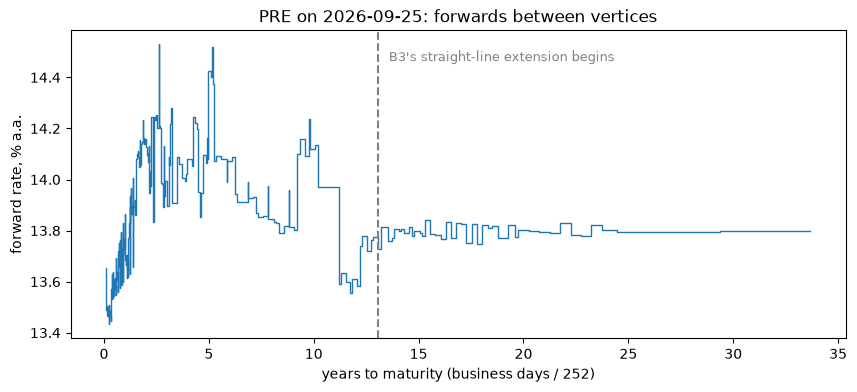

anchored through 3289 business days (~13.1 years); the file runs to 8487 (~33.7 years)
  obs_date  di_anchor_du    di_1y    di_2y  di_3y     di_5y   di_10y
2026-09-25          3289 13.60951 13.78326 13.895 13.959228 13.96681


In [8]:
anchor = bd.pre_anchor(pre)
x = pre["business_days"].to_numpy(float)
lf = x / 252 * np.log1p(pre["rate"].to_numpy(float) / 100)      # log accumulation factor
fwd = 100 * (np.exp(np.diff(lf) / np.diff(x) * 252) - 1)         # forward between vertices, % a.a.
keep = x[1:] >= 21

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(x[1:][keep] / 252, fwd[keep], where="pre", lw=1)
ax.axvline(anchor / 252, color="grey", ls="--")
ax.annotate("B3's straight-line extension begins", (anchor / 252, np.nanmax(fwd[keep])),
            xytext=(8, -12), textcoords="offset points", fontsize=9, color="grey")
ax.set_xlabel("years to maturity (business days / 252)")
ax.set_ylabel("forward rate, % a.a.")
ax.set_title("PRE on 2026-09-25: forwards between vertices")
plt.show()

print(f"anchored through {anchor} business days (~{anchor / 252:.1f} years); "
      f"the file runs to {int(x.max())} (~{x.max() / 252:.1f} years)")
print(bd.di_constant_maturity(curves).to_string(index=False))

`di_10y` is `NaN` here only if 2,520 business days fall past the anchor; on this
date they do not. Across monthly samples from 2008 to 2026 the 5-year tenor was
always anchored, and the 10-year was not in many months (8 of 12 in 2008), so
the builder leaves it null there instead of reading B3's extension as a price.

The same curves are served by the API, every vertex as published, with the rate
convention on every row. `curve_history` serves one of B3's **fixed** vertices
(nominal tenors such as 30, 90, 360 days) through time, and refuses any other
tenor rather than interpolating:

In [9]:
live = pd.DataFrame(silo.curve("PRE"))
if not live.empty:
    print(f"PRE on {live['trade_date'].iloc[0]}: {len(live)} vertices, rate_basis {live['rate_basis'].iloc[0]}")

hist = pd.DataFrame(silo.curve_history("PRE", 360))
print(hist[["trade_date", "tenor_days", "calendar_days", "business_days", "rate"]].tail(8).to_string(index=False))

try:
    silo.curve_history("PRE", 365)
except SiloError as exc:
    print("\nrefused:\n" + textwrap.fill(str(exc), 100, subsequent_indent="  "))

PRE on 2026-09-29: 280 vertices, rate_basis exp_252
trade_date  tenor_days  calendar_days  business_days   rate
2026-09-18         360            360            245 13.601
2026-09-21         360            360            247 13.530
2026-09-22         360            360            247 13.494
2026-09-23         360            362            247 13.564
2026-09-24         360            361            246 13.643
2026-09-25         360            360            245 13.606
2026-09-28         360            360            247 13.625
2026-09-29         360            360            247 13.556

refused:
HTTP 400 from https://zcjbtpxuhdekpwcxmepn.supabase.co/rest/v1/rpc/curve_history:
  {"code":"22023","details":null,"hint":null,"message":"curve_history: 365 days is not one of B3's
  fixed PRE vertices; on 2026-09-29 they were: 1, 7, 14, 21, 30, 60, 90, 120, 150, 180, 210, 240,
  270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 750, 780, 810,
  840, 870, 900, 930, 

## Step 4 — Inflation: breakevens from B3's IPCA coupon

B3 also publishes `DPL`, the clean IPCA coupon: a real rate fitted to DAP futures
(ANBIMA's NTN-B indicative rates where DAP is missing). B3's own definition of
implied inflation is $(1 + PRE)/(1 + DPL) - 1$ at the same tenor, and the builder
computes exactly that. The study first planned to use `DIC` instead, but that is
a dirty coupon taken from a poll of informants. A breakeven carries an inflation
risk premium: it is market pricing, not an expectation.

In [10]:
print(bd.breakeven_inflation(curves).round(3).to_string(index=False))

  obs_date  breakeven_1y  breakeven_2y  breakeven_5y
2026-09-25         6.422         5.955         5.851


Monthly IPCA itself comes from BACEN's SGS series, which SILO already held. It
is dated the 1st of its month and treated as public on the 15th of the next
month (a conservative assumption, not a release calendar).

## Step 5 — Sovereign risk: what a public proxy can and cannot say

Brazil's 5-year CDS is proprietary (Markit, ICE), and IPEA's copy of EMBI+
stopped on 2024-07-30. The public proxy is the **onshore dollar premium**:
B3's `DOC` curve (the clean onshore dollar coupon) minus the U.S. Treasury yield
of the same tenor. `DOC` is quoted **linear on 360 calendar days** (factor
$1 + r \cdot DC/36000$, Manual §4.5). Treasury par yields are semi-annual, so
both are converted to annual effective rates first:

In [11]:
from src.parsers.global_market import parse_treasury_par_csv

ust_rows, _ = parse_treasury_par_csv((FIX / "ust_par_yield_2026_sample.csv").read_text())
ust = pd.DataFrame(ust_rows)
ust_1y = float(ust.loc[(ust["series_id"] == "UST_PAR_1Y")
                       & (ust["observation_date"] == date(2026, 9, 25)), "value"].iloc[0])

doc_1y = bd.doc_one_year_effective(curves)["doc_1y_eff"].iloc[0]
ust_1y_eff = bd.ust_effective(pd.Series([ust_1y])).iloc[0]
print(f"DOC 1y, effective annual : {doc_1y:.3f} %")
print(f"UST 1y, effective annual : {ust_1y_eff:.3f} %  (par {ust_1y:.2f})")
print(f"onshore dollar premium   : {(doc_1y - ust_1y_eff) * 100:.0f} bp")

DOC 1y, effective annual : 6.095 %
UST 1y, effective annual : 4.551 %  (par 4.50)
onshore dollar premium   : 154 bp


The proxy was checked once, offline, against EMBI+ Brazil. It used weekly
Wednesdays from 2008-01-02 to 2024-07-24: 827 aligned weeks, measured
2026-09-27. The EMBI+ series itself is J.P. Morgan's and is not
redistributed here; the statistics are:

In [12]:
embi_check = pd.DataFrame(
    {"proxy vs EMBI+": [0.37, 0.04, 0.20, 0.41, 0.59]},
    index=["level, Pearson", "level, rank (Spearman)", "1-week changes",
           "4-week changes", "13-week changes"],
)
print(embi_check.to_string())
print("\nStress episodes, bp (start -> end of window):")
print("  2008 crisis     proxy 228 -> 516 (peak 624)   EMBI+ 248 -> 671")
print("  2015 downgrade  proxy 208 -> 369              EMBI+ 277 -> 454")
print("  COVID 2020      proxy  92 -> 109 (peak 252)   EMBI+ 189 -> 370 (peak 441)")

                        proxy vs EMBI+
level, Pearson                    0.37
level, rank (Spearman)            0.04
1-week changes                    0.20
4-week changes                    0.41
13-week changes                   0.59

Stress episodes, bp (start -> end of window):
  2008 crisis     proxy 228 -> 516 (peak 624)   EMBI+ 248 -> 671
  2015 downgrade  proxy 208 -> 369              EMBI+ 277 -> 454
  COVID 2020      proxy  92 -> 109 (peak 252)   EMBI+ 189 -> 370 (peak 441)


The proxy moves with EMBI+ over one to three months and caught the 2008 and 2015
stress. Its **level** drifts for years with onshore dollar conditions (rank
correlation 0.04), and it missed most of the 2020 widening. It is therefore
OPTIONAL, and a model should read it in changes (its momentum columns), never in
level.

## Step 6 — Global inputs, and the licence line

* **U.S. Treasury par curve** — U.S. government work, daily, from 1990.
* **Brent spot** — EIA's `RBRTE`. EIA publishes it weekly, on Wednesdays.
* **Global stress: the OFR Financial Stress Index**, in place of VIX. Cboe's Use
  of Content policy says *"You are not approved to use Cboe Content until a
  license agreement has been signed by both you and Cboe"*, and SILO ingests
  nothing that needs a licence. The VIX code stays, gated on
  `CBOE_VIX_LICENSED=1`. OFR's index is the U.S. Treasury's own work (no
  copyright; credit requested). Its Volatility category sums nine implied and
  realised vols, VIX and the swaption-based cousins of MOVE among them.
  MOVE itself is proprietary. The rates-vol stand-in is the realised
  volatility of UST 10Y changes, named `rates_vol_proxy` so nobody mistakes it
  for MOVE.

OFR says the index does not change once estimated, except as its revision
history lists. SILO keeps the value from **before** each listed revision as a
first release, and the builder uses that one:

In [13]:
from src.parsers.global_market import parse_ofr_fsi_csv, parse_ofr_fsi_revisions

current, _ = parse_ofr_fsi_csv((FIX / "ofr_fsi_sample.csv").read_text())
first, _ = parse_ofr_fsi_revisions((FIX / "ofr_fsi_revisions_sample.xlsx").read_bytes())
cur = pd.DataFrame(current).query("series_id == 'OFR_FSI'")[["observation_date", "value"]]
fr = pd.DataFrame(first).query("series_id == 'OFR_FSI_FIRST_RELEASE'")[["observation_date", "value"]]

both = cur.merge(fr, on="observation_date", how="left", suffixes=("_now", "_first_release"))
both[["value_now", "value_first_release"]] = both[["value_now", "value_first_release"]].astype(float)
both["used_by_the_builder"] = bd.prefer_first_release(
    cur.rename(columns={"observation_date": "obs_date"}),
    fr.rename(columns={"observation_date": "obs_date"}),
).set_index("obs_date").loc[both["observation_date"], "value"].to_numpy()
print(both.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

observation_date  value_now  value_first_release  used_by_the_builder
      2000-01-03      2.140                  NaN                2.140
      2000-01-04      2.421                  NaN                2.421
      2008-10-10     29.320                  NaN               29.320
      2017-10-02     -3.455               -3.605               -3.605
      2018-08-30     -2.683               -1.950               -1.950
      2022-01-03     -2.537               -2.649               -2.649
      2026-09-21     -2.727                  NaN               -2.727
      2026-09-22     -2.773                  NaN               -2.773
      2026-09-23     -2.663                  NaN               -2.663


## Step 7 — The rule: a value is on row *t* only if it was public by then

Every source keeps its own calendar as `(obs_date, value, available_date)`, and
features are joined to the B3 session grid on `available_date`, never on the
observation date. Each availability rule is written down and conservative
(later, never earlier):

In [14]:
examples = {
    "di":      date(2026, 9, 23),   # B3 session, published the same evening
    "usdbrl":  date(2026, 9, 23),
    "ust":     date(2026, 9, 23),
    "ofr":     date(2026, 9, 23),   # two U.S. business days late; a third weekday covers a holiday
    "selic":   date(2026, 9, 23),
    "brent":   date(2026, 9, 23),   # a Wednesday's price waits for next Wednesday's release, plus a day
    "monthly": date(2026, 8, 1),    # IPCA / IC-Br for August, dated the 1st
    "focus":   date(2026, 9, 18),   # published the Monday after its week, plus a day
}
table = pd.DataFrame(
    [(name, d, bd.RULES[name].available(d), bd.RULES[name].max_stale_sessions)
     for name, d in examples.items()],
    columns=["rule", "observation", "available_from", "max_stale_sessions"],
)
print(table.to_string(index=False))

   rule observation available_from  max_stale_sessions
     di  2026-09-23     2026-09-23                   0
 usdbrl  2026-09-23     2026-09-23                   5
    ust  2026-09-23     2026-09-23                   5
    ofr  2026-09-23     2026-09-28                   5
  selic  2026-09-23     2026-09-23                   5
  brent  2026-09-23     2026-10-01                  10
monthly  2026-08-01     2026-09-15                  45
  focus  2026-09-18     2026-09-22                  10


Past its staleness limit a value becomes null and the gap is counted; it is
never carried forward. One OFR observation on a short run of B3 sessions:

In [15]:
sessions_demo = [date(2026, 9, d) for d in (21, 22, 23, 24, 25, 28, 29, 30)] + \
                [date(2026, 10, d) for d in (1, 2, 5, 6, 7)]
one = bd.with_availability(pd.DataFrame({"obs_date": [date(2026, 9, 23)], "x": [-2.66]}), "ofr")
joined, nulled = bd.asof_join(sessions_demo, one, ["x"], "ofr", "x")
print(joined.to_string())
print(f"\nnulled for staleness: {nulled} session(s)")

               x x__obs_date
date                        
2026-09-21   NaN         NaT
2026-09-22   NaN         NaT
2026-09-23   NaN         NaT
2026-09-24   NaN         NaT
2026-09-25   NaN         NaT
2026-09-28 -2.66  2026-09-23
2026-09-29 -2.66  2026-09-23
2026-09-30 -2.66  2026-09-23
2026-10-01 -2.66  2026-09-23
2026-10-02 -2.66  2026-09-23
2026-10-05 -2.66  2026-09-23
2026-10-06   NaN         NaT
2026-10-07   NaN         NaT

nulled for staleness: 2 session(s)


## Step 8 — Build the matrix, then prove it never looks ahead

The builder turns all of the above into one row per B3 session, with the steps
applied in order:

* levels;
* the DI curve's slope and curvature;
* 5/21/63-session momentum and 21/63-session realised volatility, each computed
  on its source's own calendar;
* correlations of daily changes on the dates both sides observed;
* the as-of join.

The real warehouse needs an operator connection (last cell). Here it runs on
**synthetic** random walks, the same ones the CI test uses. Their calendars are
synthetic too. The B3 and U.S. calendars are weekdays with a few days dropped,
and each drops different ones, the way the two real holiday calendars differ.
The monthly series are dated the 1st of each month. A date such as 2020-12-25
can therefore appear, which B3 never trades. These are shapes to test the
machinery, not market data.

In [16]:
rng = np.random.default_rng(7)
days = pd.bdate_range("2020-01-01", "2020-12-31").date
sessions = [d for i, d in enumerate(days) if i % 37 != 5]      # a few B3 holidays
us_days = [d for i, d in enumerate(days) if i % 41 != 3]       # U.S. holidays differ
months = [date(2020, m, 1) for m in range(1, 13)]

rows, level = [], 5.0
for d in sessions:
    level += rng.normal(0, 0.03)
    for du in (1, 21, 63, 126, 252, 504, 756, 1260, 2520, 3000):
        rows.append((d, "PRE", int(du * 365 / 252), du, level + du / 1000 + rng.normal(0, 0.005)))
        rows.append((d, "DPL", int(du * 365 / 252), du, 3.0 + du / 2000 + rng.normal(0, 0.005)))
    for cd in (30, 90, 180, 360, 720, 1080):
        rows.append((d, "DOC", cd, int(cd * 252 / 365), 3.0 + rng.normal(0, 0.05)))
syn_curves = pd.DataFrame(rows, columns=["trade_date", "curve", "calendar_days", "business_days", "rate"])


def walk(dates, start, sd):
    return pd.DataFrame({"obs_date": list(dates),
                         "value": start + np.cumsum(rng.normal(0, sd, len(dates)))})


syn_series = {
    "usdbrl": walk(sessions, 5.2, 0.02),
    "ust_1y": walk(us_days, 1.5, 0.02), "ust_2y": walk(us_days, 1.6, 0.02),
    "ust_5y": walk(us_days, 1.7, 0.02), "ust_10y": walk(us_days, 1.9, 0.02),
    "ust_30y": walk(us_days, 2.3, 0.02),
    "ofr_fsi": walk(us_days, -2.0, 0.1), "ofr_fsi_volatility": walk(us_days, -0.5, 0.05),
    "brent": walk(days, 60.0, 0.8), "selic": walk(sessions, 4.5, 0.0),
    "ipca": walk(months, 0.3, 0.1), "ipca_12m": walk(months, 4.0, 0.1),
    "commodity_index": walk(months, 300.0, 5.0),
    "focus_ipca_12m": walk(sessions, 3.5, 0.01),
}
syn_futures = pd.DataFrame({"trade_date": [d for d in sessions for _ in range(3)],
                            "ticker": [t for _ in sessions for t in ("DI1F21", "DI1F22", "DI1F23")],
                            "open_interest": 1000, "contracts": 10})

matrix, nulled = bd.build(sessions, syn_curves, syn_series, syn_futures)
print(f"{matrix.shape[0]} sessions x {matrix.shape[1]} columns")
print("staleness-nulled cells per block:", {k: v for k, v in nulled.items() if v})
print(matrix[["date", "di_2y", "di_2s5s", "breakeven_2y", "ust_10y", "ofr_fsi",
              "brazil_sovereign_risk_proxy", "corr_di2y_ofr_vol_21d"]].tail(5).to_string(index=False))

255 sessions x 130 columns
staleness-nulled cells per block: {}
      date    di_2y  di_2s5s  breakeven_2y  ust_10y   ofr_fsi  brazil_sovereign_risk_proxy  corr_di2y_ofr_vol_21d
2020-12-25 4.724814 0.755997      1.425935 2.709712 -4.058110                   240.065901              -0.174768
2020-12-28 4.741966 0.762178      1.443402 2.723238 -3.915890                   240.077027              -0.195045
2020-12-29 4.766495 0.754838      1.473872 2.727117 -3.818016                   240.026331              -0.156846
2020-12-30 4.744661 0.752018      1.451687 2.717400 -3.753186                   249.788270              -0.159158
2020-12-31 4.687788 0.759772      1.395135 2.701217 -3.679446                   242.845302              -0.161412


**The property that matters for out-of-sample work:** the rows up to any date *T*
must be identical whether or not anything published after *T* exists. Rebuild
from only what was public by each cutoff and compare:

In [17]:
RULE_OF = {name: rule for name, (rule, _kind) in bd.SCALAR_SERIES.items()}


def published_by(cutoff):
    c = syn_curves[syn_curves["trade_date"] <= cutoff]
    s = {k: v[[bd.RULES[RULE_OF[k]].available(d) <= cutoff for d in v["obs_date"]]]
         for k, v in syn_series.items()}
    f = syn_futures[syn_futures["trade_date"] <= cutoff]
    return c, s, f


for cutoff in (date(2020, 3, 18), date(2020, 7, 1), date(2020, 11, 20)):
    c, s, f = published_by(cutoff)
    part, _ = bd.build([d for d in sessions if d <= cutoff], c, s, f)
    pd.testing.assert_frame_equal(
        matrix[matrix["date"] <= cutoff].reset_index(drop=True),
        part.reset_index(drop=True),
        check_dtype=False,
    )
    print(f"{cutoff}: {len(part)} rows identical with and without anything published later")

2020-03-18: 54 rows identical with and without anything published later
2020-07-01: 127 rows identical with and without anything published later
2020-11-20: 226 rows identical with and without anything published later


The same check runs in CI (`tests/test_dustin_br_builder.py`). The warehouse build
reads SILO's landing tables with the operator's read connection, which the public
API does not expose:

In [18]:
if os.getenv("POSTGRES_URL"):
    from src.store.pg_client import get_pg_client

    w_sessions, w_curves, w_series, w_futures = bd.load(get_pg_client(), date(2008, 1, 2), date.today())
    live_matrix, live_nulled = bd.build(w_sessions, w_curves, w_series, w_futures)
    print(f"{len(live_matrix)} sessions {live_matrix['date'].min()}..{live_matrix['date'].max()}")
    print("columns with no value:", [c for c in live_matrix.columns if live_matrix[c].isna().all()])
else:
    print("POSTGRES_URL is not set: the warehouse build is an operator step.\n"
          "  Dispatch Research Build (.github/workflows/research_build.yml), or, with a connection:\n"
          "  python -m research_examples.dustin_br.quality --start 2008-01-02 --end <today> --out-dir out")

OperationalError: connection to server at "db.zcjbtpxuhdekpwcxmepn.supabase.co" (15.229.185.231), port 5432 failed: FATAL:  PAM authentication failed for user "postgres"


### On the real warehouse

The same builder ran on SILO's tables through the **Research Build** workflow
(`.github/workflows/research_build.yml`, read only; run 36438910847 on
2026-09-28). Its quality report (`research_examples/dustin_br/quality.py`)
re-ran the check above on the real inputs:

* **4,645 sessions and 130 columns, 2008-01-02 to 2026-09-25.**
* **No look-ahead.** Rebuilt at 2012-09-05, 2017-05-23 and 2022-02-01 with
  every input published later removed, no row up to a cutoff changed.
* **67 of the 113 value columns are complete from the first session.** The
  other 46 start later only because a window needs its full length (the
  63-session features from 2008-04-04) or a first release (IC-Br counts as
  public from 2008-02-15, Focus from 2019-01-08, where SILO's stored history
  starts). None has a gap once it starts, except these:
  * **`di_10y`** is NULL on 814 sessions, 18%, because 10 years fell inside
    B3's extrapolated tail: 67% of 2008, 85% of 2013, 60% of 2015, 27% of 2019,
    none since 2021. `di_5y` never did.
  * **DI1 liquidity** (from 2018-01-02) has gaps on four sessions, all at the
    source. 2021-01-04 (B3's newest file is malformed) and 2021-06-10 (an
    empty archive) have no settlements. On 2018-05-10 and 2025-09-11, B3's
    files omit open interest for contracts that held positions, so the total
    is NULL rather than a partial sum.
* **Sessions.** The `PRE` grid matches B3's equity sessions exactly from 2019,
  the first year SILO holds them. Earlier, one session is missing at the
  source: B3's archive for 2015-08-27 is empty, though equities traded.

## Step 9 — What the data supports

| Series | Class | Starts | Note |
| --- | --- | --- | --- |
| DI 1Y / 2Y / 3Y / 5Y (B3 `PRE`) | **CORE** | 2008-01-02 | 5Y never in B3's tail, every session 2008-2026 |
| DI slope, curvature | **CORE** | 2008-01-02 | derived in research code |
| USDBRL (PTAX), SELIC target, IPCA | **CORE** | before 2008 | BACEN |
| UST 2Y / 5Y / 10Y / 30Y | **CORE** | 1990 | loaded from 2008 |
| OFR FSI and its Volatility category | **CORE** | 2000-01-03 | first releases; two-day lag |
| Brent | **CORE** | 1987 | weekly publication |
| Rates-vol proxy (realised UST vol) | **CORE** | 2008 + 63 sessions | not MOVE |
| DI 10Y | OPTIONAL | 2008-03-11 | NULL on 18% of sessions (B3's extrapolation); complete since 2021 |
| Breakevens 1Y / 2Y / 5Y (`PRE` vs `DPL`) | OPTIONAL | 2008-01-02 | risk premium included |
| Sovereign proxy (`DOC` − UST) | OPTIONAL | 2008-01-02 | read in changes |
| IC-Br, Focus 12-month IPCA | OPTIONAL | 2008-02-15 / 2019-01-08 | IC-Br monthly and lagged; Focus as far back as SILO stores it |
| DI1 volume, open interest | LATE-STARTING | 2018-01-02 | four sessions NULL at the source (Step 8) |

**Earliest date for a consistent CORE matrix: 2008-01-02**, with 63-session
features defined from 2008-04-04 (measured on the real build). It could move to 2004: B3's reference
files keep the same layout with `PRE` and `DOC` back to 2004, and every other
CORE series starts earlier. That load is open.

## Step 10 — What is deliberately not here

* **No model and no target.** A label for the curve 21 sessions ahead looks
  forward by construction; it is built in the modelling notebook, on top of this
  matrix.
* **No licensed data.** VIX (Cboe), MOVE (ICE) and CDS (Markit, ICE) need
  licences. EMBI+ was used once, offline, to check a proxy, and its series is
  not redistributed.
* **Open:** the futures arm of `api.panel`, the 2004–2007 reference files,
  Focus before 2019, and 2021-01-04's DI1 (B3's newest file for that day is
  malformed; its earlier versions are not). The historical backfills finished
  on 2026-09-28.

---

## The rules this notebook obeyed

* **Nothing was filled.** No forward-fill, no interpolation of a missing
  observation, no carried-forward last value; a stale value became null and was
  counted. The one interpolation, a constant maturity on `PRE`, is B3's own
  flat-forward method, and it never reaches past B3's extrapolated tail.
* **Every caveat was printed beside its number.** That covers the
  `coverage().notes`, the extrapolated long end, the rate convention of each
  curve and the level drift of the sovereign proxy.
* **Freshness came from `coverage()`**, called before anything was claimed.

The contract these rules come from is
[Conventions & limits](https://octo-98895abd.mintlify.site/api-docs/conventions);
the curve endpoints are documented at
[DI futures and B3 reference curves](https://octo-98895abd.mintlify.site/api-docs/rates).